In [ ]:
import utils
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import importlib 
importlib.reload(utils)

img = cv.imread("demos/demoB.png")
sections = utils.section(img)

plt.figure(figsize=(12, 6))

plt.subplot(1, len(sections) + 1, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(24, 6))

for i, section in enumerate(sections):
    plt.subplot(1, len(sections) + 1, i + 2)
    plt.imshow(section)
    plt.title(f"Section {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

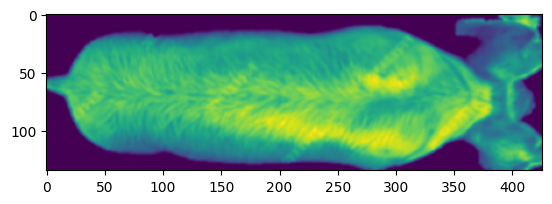

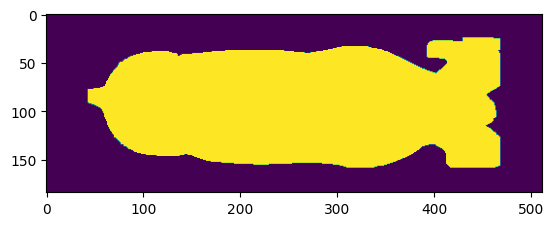

In [ ]:
img = cv.imread("demos/demoB.png")

img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img = cv.GaussianBlur(img, (5, 5), 0)

img = (img - img.min())/img.max() - img.min()

if img.shape[0] > img.shape[1]:
    img = img.T

plt.imshow(img)
plt.show()

target_width = 512
target_height = int(target_width * 0.36)
height, width = img.shape

if height < target_height or width < target_width:
    top_padding = (target_height - height) // 2
    bottom_padding = target_height - height - top_padding
    left_padding = (target_width - width) // 2
    right_padding = target_width - width - left_padding
    img = cv.copyMakeBorder(
        img,
        top_padding,
        bottom_padding,
        left_padding,
        right_padding,
        cv.BORDER_CONSTANT,
        value=0,
    )

else:
    img = cv.resize(img, (target_width, target_height))

orin_img = img.copy()

img = np.where(img > 0, 1, 0).astype(np.uint8)
plt.imshow(img)
plt.show()

#plt.imshow(img)
#plt.show()

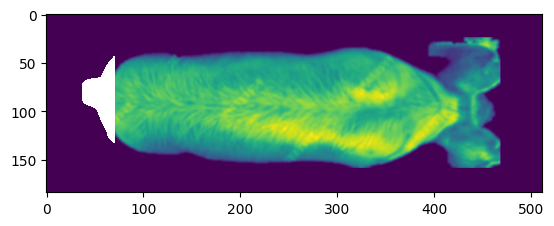

In [ ]:
tst = np.ma.masked_where((sections[0] - sections[0].min())/(sections[0].max() - sections[0].min()), orin_img)
tst.min(), tst.max()
plt.imshow(tst)
plt.show()

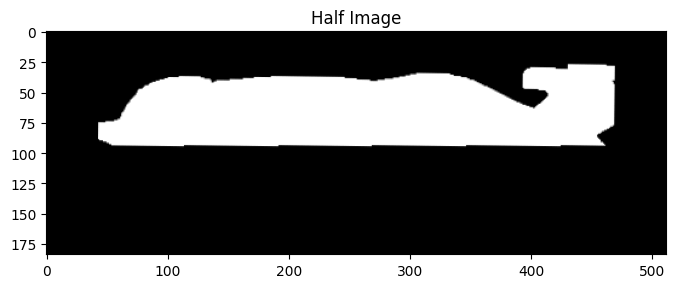

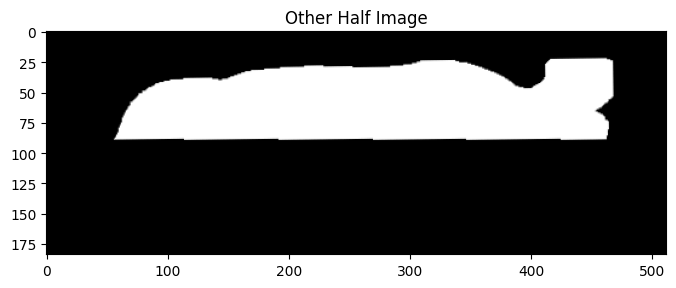

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv.contourArea)

M = cv.moments(largest_contour)
if M["m00"] != 0:
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
else:
    cX, cY = 0, 0

data_points = largest_contour[:, 0, :]  
mean = np.mean(data_points, axis=0)    
centered_data = data_points - mean 
covariance_matrix = np.cov(centered_data.T)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
max_index = np.argmax(eigenvalues)
direction = eigenvectors[:, max_index]

angle = np.arctan2(direction[1], direction[0])
angle_degrees = np.degrees(angle)

mask = np.zeros_like(img)
cv.drawContours(mask, [largest_contour], -1, (255), thickness=cv.FILLED)
half_image = np.zeros_like(img)

y_line = lambda x: (direction[1] / direction[0]) * (x - cX) + cY if direction[0] != 0 else float('inf')

for x in range(mask.shape[1]):
        y_boundary = y_line(x)
        for y in range(mask.shape[0]):
            if mask[y, x] == 255:
                if y < y_boundary:
                    half_image[y, x] = 255

lower_half_image = np.zeros_like(img)

for x in range(mask.shape[1]):
        y_boundary = y_line(x)
        for y in range(mask.shape[0]):
            if mask[y, x] == 255:
                if y > y_boundary:
                    lower_half_image[y, x] = 255

half_image = cv.resize(half_image, (img.shape[1], img.shape[0]), interpolation=cv.INTER_LINEAR)
lower_half_image = cv.resize(lower_half_image, (img.shape[1], img.shape[0]), interpolation=cv.INTER_LINEAR)


image_center = (half_image.shape[1] // 2, half_image.shape[0] // 2)
rotation_matrix = cv.getRotationMatrix2D(image_center, angle_degrees, 1.0)
img = cv.warpAffine(img, rotation_matrix, (img.shape[1], img.shape[0]), flags=cv.INTER_LINEAR)
half_image = cv.warpAffine(half_image, rotation_matrix, (half_image.shape[1], half_image.shape[0]), flags=cv.INTER_LINEAR)
lower_half_image = cv.warpAffine(lower_half_image, rotation_matrix, (lower_half_image.shape[1], lower_half_image.shape[0]), flags=cv.INTER_LINEAR)
lower_half_image = cv.flip(lower_half_image, 0)
orin_img = cv.warpAffine(orin_img, rotation_matrix, (orin_img.shape[1], orin_img.shape[0]), flags= cv.INTER_LINEAR)
plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(half_image, cv.COLOR_GRAY2BGR))
plt.title('Half Image')
plt.show()
plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(lower_half_image, cv.COLOR_GRAY2BGR))
plt.title('Other Half Image')
plt.show()


In [ ]:
kernel = np.ones((5, 5), np.uint8)
closed_image = cv.morphologyEx(half_image, cv.MORPH_CLOSE, kernel)

contours, _ = cv.findContours(closed_image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv.contourArea)

outline = np.zeros_like(closed_image)
cv.drawContours(outline, [largest_contour], -1, (255), thickness=1)

center_line_width = 50
center_row = outline.shape[0] // 2

outline[center_row + center_line_width // 2 :, :] = (
    0  # Set all rows below the center line to zero
)
outline[center_row - center_line_width // 2 :, :] = (
    0  # Set all rows below the center line to zero
)

outline = outline[::-1]

y_indices, x_indices = np.nonzero(outline)

margin = 75

valid_mask = (x_indices >= margin) & (x_indices < outline.shape[1] - margin)
filtered_y_indices = y_indices[valid_mask]
filtered_x_indices = x_indices[valid_mask]

indices = np.array(list(zip(filtered_y_indices, filtered_x_indices)))

sorted_indices = indices[np.argsort(indices[:, 1])]

if sorted_indices.size > 0:
    interp_func = interp1d(
        sorted_indices[:, 1],
        sorted_indices[:, 0],
        kind="linear",
        fill_value="extrapolate",
    )
    x_new = np.linspace(sorted_indices[:, 1].min(), sorted_indices[:, 1].max(), num=500)
    y_new = interp_func(x_new)

    interpolated_coords = np.column_stack(
        (np.round(y_new).astype(int), x_new.astype(int))
    )

    inverted_y = -interpolated_coords[:, 0]

    valleys, properties = find_peaks(inverted_y, height=None, prominence=1, distance=30)
else:
    valleys = np.array([])

num_desired_valleys = 4

if len(valleys) > 0:
    selected_valley_coords = interpolated_coords[valleys]
    selected_valley_coords = selected_valley_coords[
        np.argsort(selected_valley_coords[:, 0])[::-1]
    ]

    if len(selected_valley_coords) > num_desired_valleys:
        selected_valley_coords = selected_valley_coords[:num_desired_valleys]

    selected_valley_coords = selected_valley_coords[
        np.argsort(selected_valley_coords[:, 1])
    ]
else:
    selected_valley_coords = np.empty((0, 2))

if len(selected_valley_coords) >= 3:
    print(selected_valley_coords)
    if selected_valley_coords[2][0] > selected_valley_coords[0][0]:
        # Remove the second valley if it is deeper
        selected_valley_coords = np.delete(selected_valley_coords, 1, axis=0)
        pass

plt.figure(figsize=(5, 4))
plt.imshow(cv.cvtColor(outline, cv.COLOR_GRAY2BGR))

for valley in selected_valley_coords:
    plt.axvline(x=valley[1], color="red", linestyle="--", linewidth=1)

plt.scatter(
    selected_valley_coords[:, 1],
    selected_valley_coords[:, 0],
    color="green",
    s=25,
    label="Local Valleys",
)
plt.title(f"Local Valleys (Bottom {num_desired_valleys})")
plt.axis("off")
plt.legend()
plt.show()
outline.shape

NameError: name 'interp1d' is not defined

In [ ]:
sections = []
if len(selected_valley_coords) > 0:

    # Section 1: Legs
    start_x1 = 0
    end_x1 = selected_valley_coords[0][1]
    mask1 = np.zeros_like(img, dtype=np.uint8)
    cv.rectangle(mask1, (start_x1, 0), (end_x1, img.shape[0]), (255), thickness=-1)
    section1 = cv.bitwise_and(img, mask1)
    sections.append(section1)

    # Section 2: Body
    if len(selected_valley_coords) > 1:
        start_x2 = selected_valley_coords[0][1]
        end_x2 = selected_valley_coords[1][1]
        mask2 = np.zeros_like(img, dtype=np.uint8)
        cv.rectangle(mask2, (start_x2, 0), (end_x2, img.shape[0]), (255), thickness=-1)
        section2 = cv.bitwise_and(img, mask2)
        sections.append(section2)

    # Section 3: Shoulder
    if len(selected_valley_coords) > 2:
        start_x3 = selected_valley_coords[1][1]
        end_x3 = selected_valley_coords[2][1]
        mask3 = np.zeros_like(img, dtype=np.uint8)
        cv.rectangle(mask3, (start_x3, 0), (end_x3, img.shape[0]), (255), thickness=-1)
        section3 = cv.bitwise_and(img, mask3)
        sections.append(section3)

    # Section 4: Head
    # Works
    if len(selected_valley_coords) > 2:
        start_x4 = selected_valley_coords[2][1]
        end_x4 = img.shape[1]
        mask4 = np.zeros_like(img, dtype=np.uint8)
        cv.rectangle(mask4, (start_x4, 0), (end_x4, img.shape[0]), (255), thickness=-1)
        section4 = cv.bitwise_and(img, mask4)
        sections.append(section4)

plt.figure(figsize=(12, 6))

plt.subplot(1, len(sections) + 1, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

for i, section in enumerate(sections):
    plt.subplot(1, len(sections) + 1, i + 2)
    plt.imshow(cv.cvtColor(section, cv.COLOR_BGR2RGB))
    plt.title(f"Section {i + 1}")
    plt.axis("off")

plt.show()

print(f"Number of local valleys found: {len(selected_valley_coords)}")